# Extratropical Modes of Variability - Combined Workflow

This notebook combines the workflows from:

1. `tmp_plot_sources/plot_mov_pattern.ipynb`
2. `tmp_plot_sources/plot_mov_raweof.ipynb`
3. `tmp_plot_sources/plot_mov_batch.ipynb`

Each source notebook is kept as its own section so the pieces can still be run independently.


## Pattern Maps

Source: `tmp_plot_sources/plot_mov_pattern.ipynb`


# Extratropical Modes of Variability — Pattern Maps (Single Mode)

Plots PMP variability mode EOF patterns and teleconnection slopes for E3SM models vs. observations,
using `pcmdi_mov_reader.EMOVDiagReader` and `movs_plotter.ExtrapropicalModeMapPlotter`.

**Notebook structure:**
1. Imports (including `ExtrapropicalModeMapPlotter`)
2. Shared configuration (paths, modes, models, reader + plotter)
3. Single mode / season figure — edit `MODE_TO_PLOT` and `TOKEN_TO_PLOT` then run

> For batch plotting over all modes × all seasons, see [`plot_mov_batch.ipynb`](tmp_plot_sources/plot_mov_batch.ipynb).

In [65]:
import os
import sys
from pathlib import Path
from typing import Dict, Sequence, Optional, Tuple, Any, List

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import math

conda_prefix = Path(os.environ.get("CONDA_PREFIX", "/home/ac.szhang/.conda/envs/zppy-pcmdi-diags"))
proj_data_dir = conda_prefix / "share" / "proj"
if (proj_data_dir / "proj.db").exists():
    os.environ["PROJ_LIB"] = str(proj_data_dir)
    os.environ["PROJ_DATA"] = str(proj_data_dir)
    try:
        import pyproj
        pyproj.datadir.set_data_dir(str(proj_data_dir))
    except Exception as exc:
        print(f"Warning: could not set pyproj data dir: {exc}")

import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

for package_root in (Path("."), Path("..")):
    for module_dir in (package_root / "scripts", package_root / "util"):
        if module_dir.exists():
            sys.path.insert(0, str(module_dir.resolve()))
    if (package_root / "scripts").exists() or (package_root / "util").exists():
        break

from pcmdi_mov_reader import (
    ModeFileSpec,
    EMOVDiagReader
)

from movs_plotter import (
    ExtrapropicalModeMapPlotter,
    MultimodelPCTimeSeriesPlotter
)


## Shared Configuration

Run this cell once before any plotting cells below. Defines paths, the mode registry, model list, and instantiates the reader and plotter.

In [ ]:
TOP_DIR  = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_rrm_paper"
DATA_DIR = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi"
FIG_DIR  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper"
os.makedirs(FIG_DIR, exist_ok=True)

# Mode configuration: EOF component, driving variable, obs dataset, and optional
# regional bounds (lat_bnds/lon_bnds) used for pattern plots and stats.
mode_dict = {
    # SST-based ocean modes
    "AMO":  {"eof": "eof1", "var": "ts",  "obs": "HadISST2",  "lat_bnds": (0, 70),    "lon_bnds": (-80, 0)},
    "PDO":  {"eof": "eof1", "var": "ts",  "obs": "HadISST2"},
    "NPGO": {"eof": "eof2", "var": "ts",  "obs": "HadISST2"},
    # Northern Hemisphere SLP modes
    "NAM":  {"eof": "eof1", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (20, 90),   "lon_bnds": (-180, 180)},
    "NAO":  {"eof": "eof1", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (20, 80),   "lon_bnds": (-80, 40)},
    "NPO":  {"eof": "eof2", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (20, 80),   "lon_bnds": (120, -120)},  # lon wrap
    "PNA":  {"eof": "eof1", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (20, 80),   "lon_bnds": (120, -60)},
    # Southern Hemisphere SLP modes
    "SAM":  {"eof": "eof1", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (-90, -20), "lon_bnds": (-180, 180)},
    "PSA1": {"eof": "eof2", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (-90, -20), "lon_bnds": (120, -60)},
    "PSA2": {"eof": "eof3", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (-90, -20), "lon_bnds": (120, -60)},
}

MODEL = [
    "v3.LR.amip_0101",
    "v3.NARRM.amip_0101",
    "v3.NARRM_r0125.amip_0101",
    "v3.EARRM.amip_0101",
    "v3.AMZRRM.amip_0101",
]
MODEL_LABELS = ["LR", "NARRM", "NARRM_r0125", "EARRM", "AMZRRM"]
PERIOD = (1985, 2014)

obs_dataset_map = {m: cfg["obs"] for m, cfg in mode_dict.items()}

if ("EMOVDiagReader" not in globals() or "ExtrapropicalModeMapPlotter" not in globals() or "MultimodelPCTimeSeriesPlotter" not in globals()):
    import sys
    from pathlib import Path
    for package_root in (Path("."), Path("..")):
        for module_dir in (package_root / "scripts", package_root / "util"):
            if module_dir.exists():
                sys.path.insert(0, str(module_dir.resolve()))
        if (package_root / "scripts").exists() or (package_root / "util").exists():
            break
    from pcmdi_mov_reader import ModeFileSpec, EMOVDiagReader
    from movs_plotter import ExtrapropicalModeMapPlotter, MultimodelPCTimeSeriesPlotter
    from pcmdi_mov_workflow import plot_pcmdi_mode_outputs, resolve_mode_spec

reader = EMOVDiagReader(
    data_dir=DATA_DIR,
    prefer_cbf=True,
    obs_key="obs",
    model_key="e3sm",
    target_lat_name="latitude",
    target_lon_name="longitude_a",
    obs_dataset_map=obs_dataset_map,
    normalize_lon_360=True,
    sort_latlon=True,
)

plotter = ExtrapropicalModeMapPlotter(
    fig_dir=FIG_DIR,
    plot_dict={"reference": {"label": "Obs"}, "hist": {"label": "E3SM"}},
    group_order=("hist",),
    obs_key="reference",
    lat_name="latitude",
    lon_name="longitude_a",
)

pc_plotter = MultimodelPCTimeSeriesPlotter(
    fig_dir=FIG_DIR,
    plot_dict={
        "reference": {"label": "Obs"},
        "hist": {"label": "E3SM"},
    },
    group_order=("hist",),
    obs_key="reference",
)


## Single Mode / Season Figure

Edit `MODE_TO_PLOT` and `TOKEN_TO_PLOT` then run this cell to produce:
- **Figure 1** — regional EOF pattern map (obs + all models, with r / RMSE annotations)
- **Figure 2** — global teleconnection slope map (obs + all models)

Saved: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/NAO_DJF_psl_eof1_MODE_PATTERN_region.pdf
Saved: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/NAO_DJF_psl_eof1_TELECONNECTION_global.pdf
Saved: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/NAO_DJF_psl_eof1_PC_timeseries.pdf


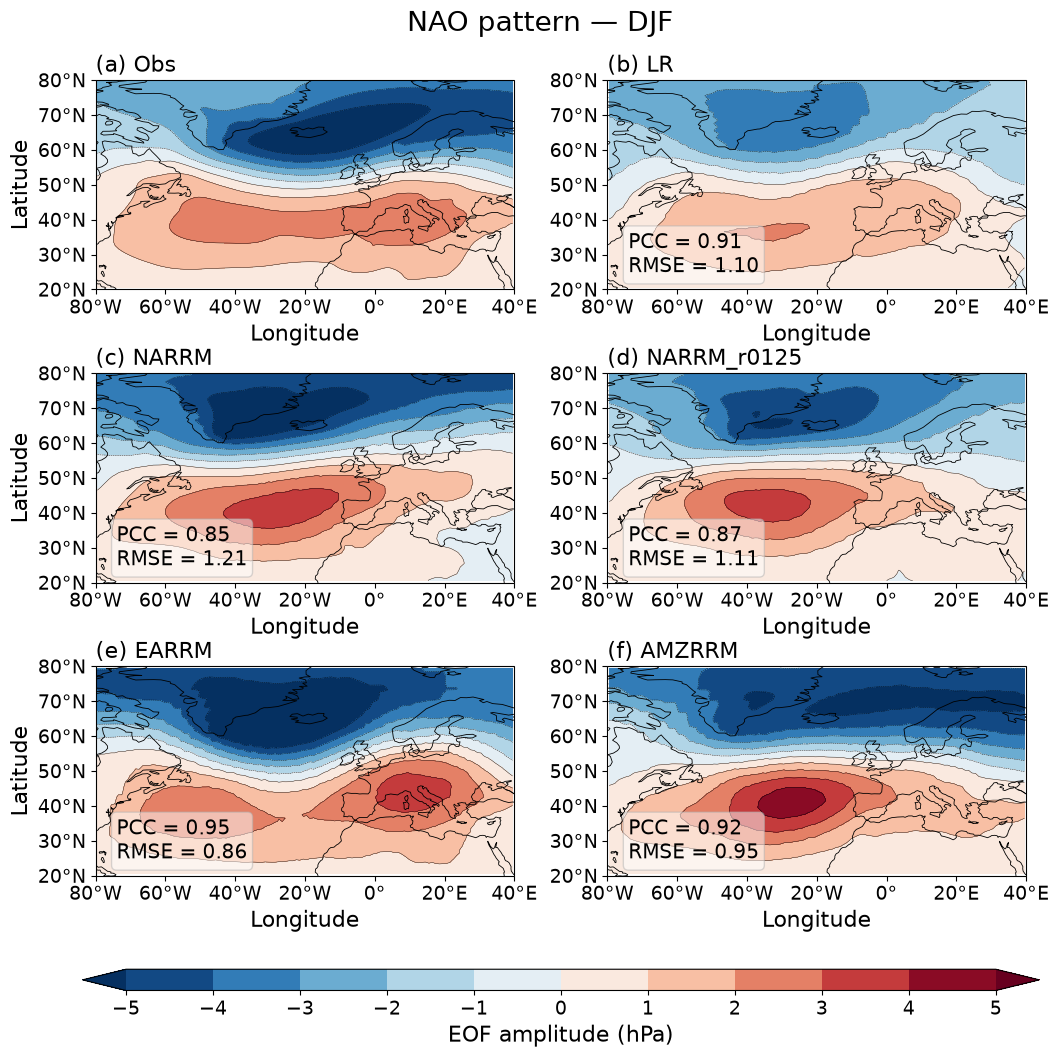

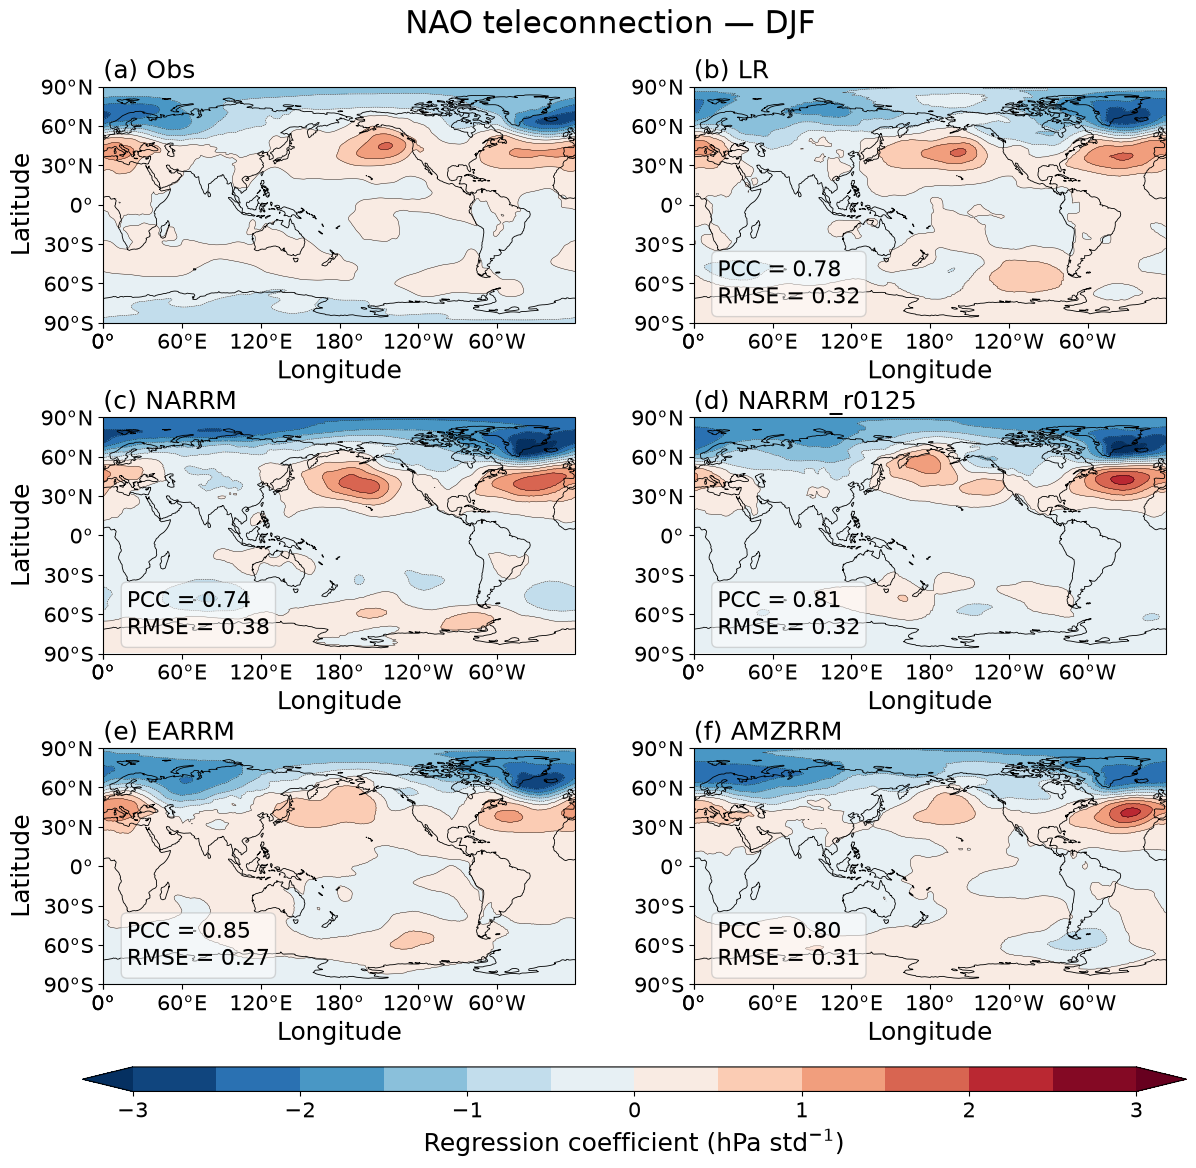

In [ ]:
# ── PCMDI file plot setup: edit values here ──────────────────────────────────
MODE_TO_PLOT  = "NAO"   # any key from mode_dict
TOKEN_TO_PLOT = "DJF"   # psl: DJF/MAM/JJA/SON/monthly/yearly | ts: monthly/yearly

PCMDI_PATTERN_CONFIG = dict(
    which="eof",
    filename_template="{mode}_{token}_{var}_{eof}_MODE_PATTERN_region.pdf",
    lon_convention="negpos",
    central_lon=0.0,
    ncols=2,
    figsize_per_panel=(5.2, 3.6),
    fontz=16,
    fig_dpi=300,
    fig_format="pdf",
    xtick_step=20.0,
    yticks=None,
    wspace=0.15,
    hspace=0.40,
    cb_pad=0.10,
    cmap="RdBu_r",
    mlevels=np.array([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5], dtype=float),
    cbar_ticks=np.array([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5], dtype=float),
    cbar_tick_labels=None,
    cbar_label="EOF amplitude (hPa)",
    area_weight=True,
)

PCMDI_TELECONNECTION_CONFIG = dict(
    which="slope",
    filename_template="{mode}_{token}_{var}_{eof}_TELECONNECTION_global.pdf",
    central_lon=180.0,
    ncols=2,
    figsize_per_panel=(6, 4),
    fontz=18,
    fig_dpi=300,
    fig_format="pdf",
    xtick_step=60.0,
    yticks=np.arange(-90, 91, 30),
    wspace=0.15,
    hspace=0.40,
    cb_pad=0.08,
    cmap="RdBu_r",
    mlevels=np.array([-3, -2.5, -2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5, 3], dtype=float),
    cbar_ticks=np.array([-3, -2, -1, 0, 1, 2, 3], dtype=float),
    cbar_tick_labels=None,
    cbar_label="Regression coefficient (hPa std$^{-1}$)",
    area_weight=True,
)

PCMDI_PC_CONFIG = dict(
    which="pc",
    filename_template="{mode}_{token}_{var}_{eof}_PC_timeseries.pdf",
    pc_var="pc",  # label only; PCMDI-file block reads the NetCDF variable named "pc"
    member_dim="member",
    obs_label=None,
    model_styles={
        "LR": {"color": "tab:blue", "linestyle": "-", "marker": "o"},
        "NARRM": {"color": "tab:orange", "linestyle": "-", "marker": "s"},
        "NARRM_r0125": {"color": "tab:orange", "linestyle": "--", "marker": "s"},
        "EARRM": {"color": "tab:green", "linestyle": "-", "marker": "^"},
        "AMZRRM": {"color": "tab:purple", "linestyle": "-", "marker": "D"},
    },
    fig_dpi=400,
    fig_format="pdf",
    figsize=(14, 6),
    fontz=18,
    obs_bar_width=0.80,
    obs_bar_alpha=0.30,
    obs_bar_color="black",
    obs_bar_edgecolor="black",
    obs_bar_linewidth=0.8,
    linewidth_model=2.5,
    markersize=8.0,
    markeredgewidth=1.0,
    alpha_model=0.95,
    use_time_coord=True,
    time_coord_offset=-1 if TOKEN_TO_PLOT == "DJF" else 0,
    xlim=(PERIOD[0] - 0.5, PERIOD[1] + 0.5),
    xtick_step=2,
    xtick_start=PERIOD[0] + (PERIOD[0] % 2),
    xtick_end=PERIOD[1],
    sort_by_corr=True,
    zero_line_color="0.25",
    zero_linewidth=1.2,
    zero_linestyle="--",
    zero_alpha=0.85,
    grid=True,
    grid_axis="y",
    grid_linestyle="--",
    grid_linewidth=0.6,
    grid_alpha=0.35,
    ylabel="Standardized PC",
    xlabel="Time",
    title=None,
    ylim=None,
    legend_below=True,
    legend_frameon=True,
    legend_edgecolor="black",
    legend_facecolor="white",
    legend_framealpha=1.0,
    legend_ncol=3,
    legend_stat="std_ratio",  # "std_ratio", "var_ratio", "corr", or "none"
    show_corr=True,
    show_corr_significance=True,
    show_corr_pvalue=False,
    corr_prefix="COR",
    corr_fmt="{:.2f}",
    corr_label_style="raw",
)

# ──────────────────────────────────────────────────────────────────────────────

import sys
from pathlib import Path
for package_root in (Path("."), Path("..")):
    for module_dir in (package_root / "scripts", package_root / "util"):
        if module_dir.exists() and str(module_dir.resolve()) not in sys.path:
            sys.path.insert(0, str(module_dir.resolve()))
    if (package_root / "scripts").exists() or (package_root / "util").exists():
        break

from pcmdi_mov_workflow import plot_pcmdi_mode_outputs, resolve_mode_spec

mode_cfg, spec = resolve_mode_spec(mode_dict, MODE_TO_PLOT, TOKEN_TO_PLOT, PERIOD)

PCMDI_PC_CONFIG = dict(PCMDI_PC_CONFIG)
PCMDI_PC_CONFIG["obs_label"] = PCMDI_PC_CONFIG["obs_label"] or mode_cfg["obs"]
PCMDI_PC_CONFIG["title"] = PCMDI_PC_CONFIG["title"] or (
    f"{MODE_TO_PLOT} ({TOKEN_TO_PLOT}, {PERIOD[0]}-{PERIOD[1]}) | "
    "Standardized Projected Principal Component (projected onto OBS EOF)"
)

pcmdi_outputs = plot_pcmdi_mode_outputs(
    reader=reader,
    map_plotter=plotter,
    pc_plotter=pc_plotter,
    model_tags=MODEL,
    member_labels=MODEL_LABELS,
    mode_dict=mode_dict,
    mode=MODE_TO_PLOT,
    token=TOKEN_TO_PLOT,
    period=PERIOD,
    pattern_config=PCMDI_PATTERN_CONFIG,
    teleconnection_config=PCMDI_TELECONNECTION_CONFIG,
    pc_config=PCMDI_PC_CONFIG,
)


## Raw EOF Analysis

Source: `tmp_plot_sources/plot_mov_raweof.ipynb`


# Extratropical Modes of Variability — Raw EOF Analysis

Computes EOF patterns, PCs, teleconnection slopes, and variance fractions directly from
model / obs raw fields, using `movs_analyzer.py` and explicit data-source dictionaries in this notebook.

**Notebook structure:**
1. Imports
2. Shared configuration (period, mode, season, model list)
3. Run analysis (obs + all models)

> For plotting pre-computed PMP diagnostic outputs, see [`plot_mov_pattern.ipynb`](tmp_plot_sources/plot_mov_pattern.ipynb).

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import sys
import string 
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

conda_prefix = Path(os.environ.get("CONDA_PREFIX", "/home/ac.szhang/.conda/envs/zppy-pcmdi-diags"))
proj_data_dir = conda_prefix / "share" / "proj"
if (proj_data_dir / "proj.db").exists():
    os.environ["PROJ_LIB"] = str(proj_data_dir)
    os.environ["PROJ_DATA"] = str(proj_data_dir)
    try:
        import pyproj
        pyproj.datadir.set_data_dir(str(proj_data_dir))
    except Exception as exc:
        print(f"Warning: could not set pyproj data dir: {exc}")
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.colors as mcolors
from cartopy.util import add_cyclic_point
import matplotlib.ticker as mticker

for package_root in (Path("."), Path("..")):
    for module_dir in (package_root / "scripts", package_root / "util"):
        if module_dir.exists():
            sys.path.insert(0, str(module_dir.resolve()))
    if (package_root / "scripts").exists() or (package_root / "util").exists():
        break

from movs_analyzer import ModeAnalyzer
from movs_plotter import add_sig_dots, ExtrapropicalModeMapPlotter, MultimodelPCTimeSeriesPlotter
from pcmdi_mov_workflow import plot_raw_mode_pattern, plot_raw_teleconnection, plot_raw_pc_timeseries


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Shared Configuration

Edit the settings below, then run this cell and the analysis cell.

In [ ]:
# ── User settings ────────────────────────────────────────────────────────────
mode   = "NAO"   # any key in MODE_CONFIG
season = "DJF"   # MONTHLY | ANNUAL | DJF | MAM | JJA | SON | None (use config default)
period = (1985, 2014)

model_list = ["LR", "NARRM", "NARRM_r0125", "EARRM", "AMZRRM"]  # keys in MODEL_DATASETS

custom_obs_path = None   # set to a file path to override the config default
custom_obs_name = None   # optional label when using custom_obs_path

# Significance levels used during plotting (choose one or both at plot time).
# The raw p-value map (slope_pval / slope_pval_proj) is saved in the NetCDF,
# so you can apply any threshold later without re-running the analysis.
SIG_LEVELS = [0.05, 0.10]

# Set OVERWRITE = True to force recomputation even if cached files already exist.
# Useful after changing analysis code or fixing bugs. Reset to False when done.
OVERWRITE = True

# Shared output directory for all cached NetCDF results.
# Files are named {mode}_{season}_{y0}-{y1}_{obs_name}_{case_name}.nc
# so files for different modes / seasons / periods / obs never overwrite each other.
OUT_DIR = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper"
FIG_DIR = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
# Explicit data sources for this notebook. Keeping these here avoids hidden
# dependencies on external config files when regenerating paper diagnostics.
MODEL_DATA_ROOT = "/lcrc/group/e3sm2/ac.qtang/E3SMv3"
MODEL_SUBDIR = "post/atm/180x360_aave/cmip_ts/monthly"
MODEL_DATASETS = {
    "LR":          {"name": "v3.LR.amip_0101",          "dir": MODEL_DATA_ROOT, "subdir": MODEL_SUBDIR},
    "NARRM":       {"name": "v3.NARRM.amip_0101",       "dir": MODEL_DATA_ROOT, "subdir": MODEL_SUBDIR},
    "NARRM_r0125": {"name": "v3.NARRM_r0125.amip_0101", "dir": MODEL_DATA_ROOT, "subdir": MODEL_SUBDIR},
    "EARRM":       {"name": "v3.EARRM.amip_0101",       "dir": MODEL_DATA_ROOT, "subdir": MODEL_SUBDIR},
    "AMZRRM":      {"name": "v3.AMZRRM.amip_0101",      "dir": MODEL_DATA_ROOT, "subdir": MODEL_SUBDIR},
}

OBS_SOURCES = {
    "psl": {"name": "NOAA-20C", "data": "/lcrc/group/e3sm/diagnostics/observations/obs4MIPs_PCMDI_monthly/NOAA-20C/psl_183601_201512.nc"},
    "ts":  {"name": "HadISST2", "data": "/lcrc/group/e3sm/diagnostics/observations/obs4MIPs_PCMDI_monthly/HadISST2/ts_186901_202212.nc"},
}

MODE_CONFIG = {
    "AMO":     {"type": "eof",   "eof_num": 1, "var": "ts",  "lat_bnds": (0, 70),    "lon_bnds": (-80, 0),    "season": "annual",  "obs": OBS_SOURCES["ts"]},
    "PDO":     {"type": "eof",   "eof_num": 1, "var": "ts",                                      "season": "annual",  "obs": OBS_SOURCES["ts"]},
    "NPGO":    {"type": "eof",   "eof_num": 2, "var": "ts",                                      "season": "annual",  "obs": OBS_SOURCES["ts"]},
    "NAM":     {"type": "eof",   "eof_num": 1, "var": "psl", "lat_bnds": (20, 90),   "lon_bnds": (-180, 180), "season": "DJF",     "obs": OBS_SOURCES["psl"]},
    "NAO":     {"type": "eof",   "eof_num": 1, "var": "psl", "lat_bnds": (20, 80),   "lon_bnds": (-80, 40),   "season": "DJF",     "obs": OBS_SOURCES["psl"]},
    "NPO":     {"type": "eof",   "eof_num": 2, "var": "psl", "lat_bnds": (20, 80),   "lon_bnds": (120, -120), "season": "DJF",     "obs": OBS_SOURCES["psl"]},
    "PNA":     {"type": "eof",   "eof_num": 1, "var": "psl", "lat_bnds": (20, 80),   "lon_bnds": (120, -60),  "season": "DJF",     "obs": OBS_SOURCES["psl"]},
    "SAM":     {"type": "eof",   "eof_num": 1, "var": "psl", "lat_bnds": (-90, -20), "lon_bnds": (-180, 180), "season": "annual",  "obs": OBS_SOURCES["psl"]},
    "PSA1":    {"type": "eof",   "eof_num": 2, "var": "psl", "lat_bnds": (-90, -20), "lon_bnds": (120, -60),  "season": "annual",  "obs": OBS_SOURCES["psl"]},
    "PSA2":    {"type": "eof",   "eof_num": 3, "var": "psl", "lat_bnds": (-90, -20), "lon_bnds": (120, -60),  "season": "annual",  "obs": OBS_SOURCES["psl"]},
    "NINO3.4": {"type": "index", "var": "ts",  "lat_bnds": (-5, 5),    "lon_bnds": (-170, -120), "season": "monthly", "index_method": "area_mean", "obs": OBS_SOURCES["ts"]},
    "NINO3":   {"type": "index", "var": "ts",  "lat_bnds": (-5, 5),    "lon_bnds": (-150, -90),  "season": "monthly", "index_method": "area_mean", "obs": OBS_SOURCES["ts"]},
    "NINO4":   {"type": "index", "var": "ts",  "lat_bnds": (-5, 5),    "lon_bnds": (160, -150),  "season": "monthly", "index_method": "area_mean", "obs": OBS_SOURCES["ts"]},
}
# ─────────────────────────────────────────────────────────────────────────────

analyzer = ModeAnalyzer({"datasets": MODEL_DATASETS, "modes": MODE_CONFIG})

## Run Analysis

For each obs / model, checks whether a cached NetCDF already exists in `OUT_DIR`:
- **Found** → loads it directly (fast path); if proj variables or `psl_anom` are missing they are recomputed and the file is updated
- **Not found** → runs the full EOF pipeline, saves to `OUT_DIR`, then continues

### Variables saved per dataset

| Variable | Description |
|---|---|
| `eof` | Independent EOF spatial pattern |
| `pc` | Standardized PC (independent EOF) |
| `frac` | Explained variance fraction |
| `eof_lr` | Reconstructed/common-base EOF map, PCMDI-style (`slope + intercept` for standardized PC) |
| `slope` | Regression of full field onto `pc` |
| `intercept` | Regression intercept for `pc` |
| `slope_pval` | Two-tailed p-value of `slope` (t-test, df = n−2) |
| `corr` | Pearson r with `pc` |
| `psl_anom` | Full-domain PSL anomaly used for regression diagnostics; saved for PSL modes |
| `pc_proj` | Standardized PC from projection onto **obs EOF** (common base) |
| `eof_lr_proj` | Reconstructed common-base map from projection onto obs EOF |
| `slope_proj` | Regression of full field onto `pc_proj` |
| `intercept_proj` | Regression intercept for `pc_proj` |
| `slope_pval_proj` | Two-tailed p-value of `slope_proj` |
| `corr_proj` | Pearson r with `pc_proj` |

Both `slope_pval` and `slope_pval_proj` store **raw continuous p-values** (0–1).
Apply any threshold at plot time: `ds["slope_pval"] < 0.05`, `< 0.10`, etc.

EOF analysis uses the PCMDI Metrics variability-mode helper when available, then falls back to `eofs`, then to a local SVD implementation.


In [ ]:
print(f"Mode: {mode} | Season: {season} | Period: {period[0]}-{period[1]}")
print(f"Output dir: {OUT_DIR}")
print(f"Expected filenames: {mode}_{season}_{period[0]}-{period[1]}_<obs>_<case>.nc")
print(f"Overwrite: {OVERWRITE}\n")

obs_ds, model_results = analyzer.analyze_or_load_all(
    mode_name=mode,
    model_list=model_list,
    out_dir=OUT_DIR,
    custom_obs_path=custom_obs_path,
    custom_obs_name=custom_obs_name,
    period=period,
    season=season,
    overwrite=OVERWRITE,
)

obs_info = analyzer.cfg.get_mode_info(mode).get("obs", {})
obs_panel_label = custom_obs_name or (obs_info.get("name") if isinstance(obs_info, dict) else str(obs_info)) or "Obs"

# ── Summary ───────────────────────────────────────────────────────────────────
def _sig_pct(ds, key, level):
    if key not in ds:
        return "  n/a  "
    return f"{(ds[key].values < level).mean() * 100:5.1f}%"

hdr_parts = ["frac"]
for lv in SIG_LEVELS:
    hdr_parts += [f"indep p<{lv:.2f}", f"proj p<{lv:.2f}"]
print(f"  {'name':20s}  " + "  ".join(f"{h:>12}" for h in hdr_parts))
print(f"  {'-'*20}  " + "  ".join(["-"*12] * len(hdr_parts)))

all_cases = [(obs_panel_label, obs_ds)] + list(model_results.items())
for name, ds in all_cases:
    row = [f"{float(ds['frac']):.3f}      "]
    for lv in SIG_LEVELS:
        row += [_sig_pct(ds, "slope_pval", lv), _sig_pct(ds, "slope_pval_proj", lv)]
    print(f"  {name:20s}  " + "  ".join(f"{v:>12}" for v in row))

Mode: NAO | Season: DJF | Period: 1985-2014
Output dir: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper
Expected filenames: NAO_DJF_1985-2014_<obs>_<case>.nc
Overwrite: True

  Overwrite=True — recomputing obs (NOAA-20C) …
  Computing obs (NOAA-20C) …


2026-06-19 05:35:20,377 [WARNING]: dataset.py(decode_time:412) >> 'time' does not have a calendar attribute set. Defaulting to CF 'standard' calendar.


Converting units by  multiply 0.01
  Saved → /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/NAO_DJF_1985-2014_NOAA-20C_NOAA-20C.nc
  Using in-memory obs EOF solver/reference grid for PCMDI CBF projection.
  Overwrite=True — recomputing LR …
  Computing LR …
Converting units by  multiply 0.01


/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_rrm_paper/pcmdi_package/scripts/movs_analyzer.py:29: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  from scipy import stats


  Saved → /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/NAO_DJF_1985-2014_NOAA-20C_LR.nc
  Overwrite=True — recomputing NARRM …
  Computing NARRM …
Converting units by  multiply 0.01


...

  Saved → /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/NAO_DJF_1985-2014_NOAA-20C_NARRM_r0125.nc
  Overwrite=True — recomputing EARRM …
  Computing EARRM …
Converting units by  multiply 0.01


/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_rrm_paper/pcmdi_package/scripts/movs_analyzer.py:29: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  from scipy import stats


  Saved → /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/NAO_DJF_1985-2014_NOAA-20C_EARRM.nc
  Overwrite=True — recomputing AMZRRM …
  Computing AMZRRM …
Converting units by  multiply 0.01


/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_rrm_paper/pcmdi_package/scripts/movs_analyzer.py:29: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  from scipy import stats


  Saved → /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/NAO_DJF_1985-2014_NOAA-20C_AMZRRM.nc
  name                          frac  indep p<0.05   proj p<0.05  indep p<0.10   proj p<0.10
  --------------------  ------------  ------------  ------------  ------------  ------------
  NOAA-20C               0.470               29.9%         n/a           36.1%         n/a  
  LR                     0.332               13.4%         17.0%         17.7%         21.5%
  NARRM                  0.500               31.2%         28.3%         39.7%         33.8%
  NARRM_r0125            0.405               31.4%         30.8%         44.5%         40.9%
  EARRM                  0.573               36.0%         31.9%         45.2%         41.3%
  AMZRRM                 0.570               28.2%         26.4%         35.3%         31.3%


### Direct NOAA-20C EOF Check: PCMDI File vs Raw EOF Cache

This diagnostic compares the PCMDI Metrics NOAA-20C reconstructed/common-base EOF NetCDF directly with the observational common-base map generated by the raw EOF analysis block above. It is intentionally independent of the panel plotting code.


PCMDI obs EOF: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi/v3.NARRM.amip_0101/pcmdi_diags/model_vs_obs/metrics_data/variability_modes/NAO/NOAA-20C/NAO_psl_EOF1_DJF_obs_1985-2014.nc
Raw obs EOF:   /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/NAO_DJF_1985-2014_NOAA-20C_NOAA-20C.nc

Time coordinate
  PCMDI: n=30, first=1986-01-01T00:00:00.000000000, last=2015-01-01T00:00:00.000000000
  Raw:   n=30, first=1986-01-01T00:00:00.000000000, last=2015-01-01T00:00:00.000000000

Metadata
  PCMDI frac: 0.473068
  Raw frac:   0.470434
  Raw solver: pcmdi_metrics.eof_analysis_get_variance_mode
  Raw module: /home/ac.szhang/code/pcmdi_metrics/pcmdi_metrics/variability_mode/lib/eof_analysis.py

Common-base map statistics after raw Pa -> hPa conversion
  PCMDI     : min=  -6.258, max=   3.417, std=   1.219
  Raw       : min=  -6.211, max=   3.431, std=   1.213
  Raw-PCMDI : min=  -0.072, max=   0.058, std=   0.021

Weighted pattern PCC = 0.9999
Weighted RM

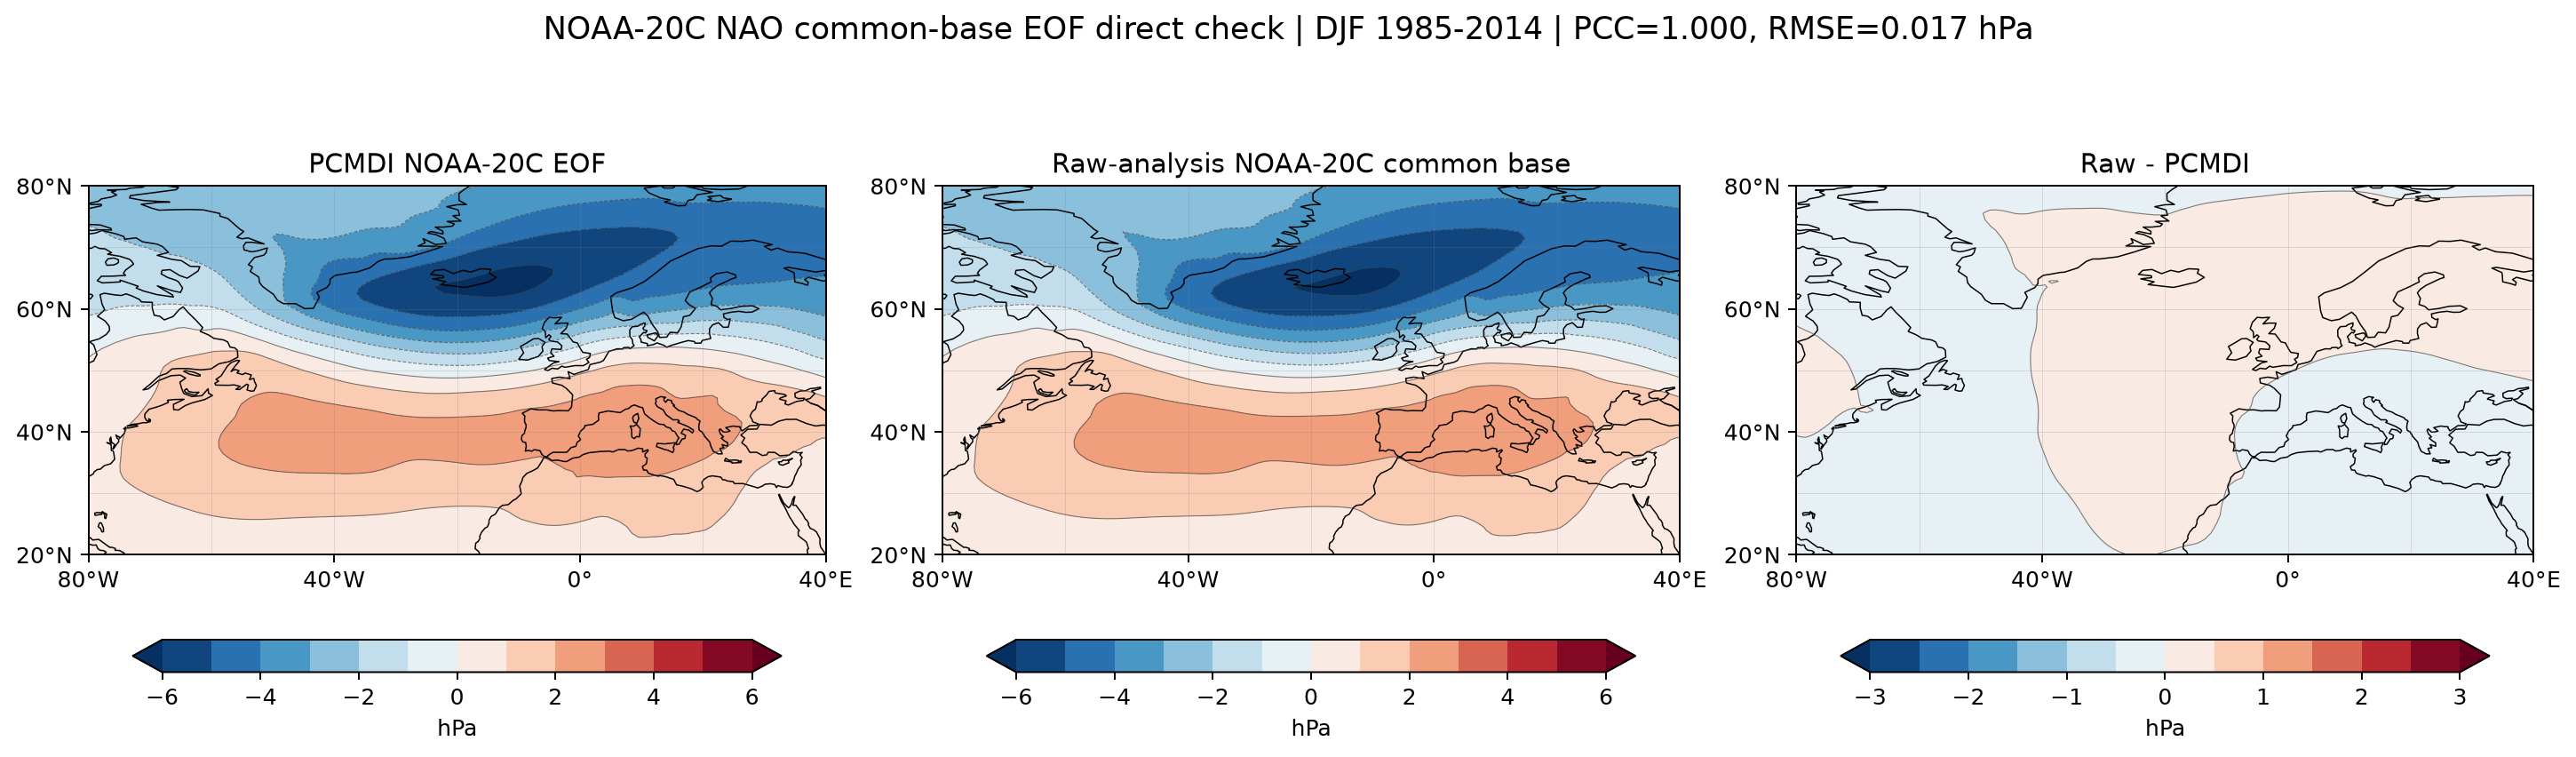

In [ ]:
# Direct comparison: PCMDI NOAA-20C obs EOF vs raw-analysis observational common-base map
PCMDI_OBS_EOF_PATH = Path(
    "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi/"
    "v3.NARRM.amip_0101/pcmdi_diags/model_vs_obs/metrics_data/"
    "variability_modes/NAO/NOAA-20C/NAO_psl_EOF1_DJF_obs_1985-2014.nc"
)

raw_obs_tag = obs_panel_label or "NOAA-20C"
RAW_OBS_EOF_PATH = Path(OUT_DIR) / f"{mode}_{season}_{period[0]}-{period[1]}_{raw_obs_tag}_{raw_obs_tag}.nc"

print(f"PCMDI obs EOF: {PCMDI_OBS_EOF_PATH}")
print(f"Raw obs EOF:   {RAW_OBS_EOF_PATH}")

pcmdi_obs = xr.open_dataset(PCMDI_OBS_EOF_PATH).load()
raw_obs = xr.open_dataset(RAW_OBS_EOF_PATH).load()


def _time_summary(ds):
    if "pc" not in ds or "time" not in ds["pc"].dims:
        return "n/a"
    t = ds["pc"].time
    return f"n={t.size}, first={t.values[0]}, last={t.values[-1]}"


def _to_0360(da):
    if "lon" in da.coords:
        da = da.assign_coords(lon=((da.lon + 360) % 360)).sortby("lon")
    return da


def _weighted_pcc_rmse(a, b):
    a, b = xr.align(a, b, join="inner")
    mask = np.isfinite(a) & np.isfinite(b)
    w = np.cos(np.deg2rad(a.lat)).broadcast_like(a).where(mask)
    a = a.where(mask)
    b = b.where(mask)
    wsum = w.sum()
    amean = (a * w).sum() / wsum
    bmean = (b * w).sum() / wsum
    aanom = a - amean
    banom = b - bmean
    pcc = ((aanom * banom * w).sum() / np.sqrt((aanom**2 * w).sum() * (banom**2 * w).sum()))
    rmse = np.sqrt(((a - b) ** 2 * w).sum() / wsum)
    return float(pcc), float(rmse)


def _field_summary(label, da):
    return (
        f"{label:10s}: min={float(da.min()):8.3f}, max={float(da.max()):8.3f}, "
        f"std={float(da.std()):8.3f}"
    )

# PCMDI obs "eof" is the reconstructed/common-base map (eof_lr_obs_domain).
# The raw-analysis observational common-base equivalent is raw_obs["eof_lr"].
# New raw-analysis caches are already PCMDI-normalized to hPa; older caches
# used Pa, so keep backward-compatible scaling.
pcmdi_eof = _to_0360(pcmdi_obs["eof"])
raw_scale = 1.0 if str(raw_obs.attrs.get("analysis_units", "")).lower() == "hpa" else 0.01
raw_eof = _to_0360(raw_obs["eof_lr"] * raw_scale)
raw_eof.attrs["units"] = "hPa"

pcc, rmse = _weighted_pcc_rmse(raw_eof, pcmdi_eof)
if pcc < 0:
    raw_eof = -raw_eof
    pcc, rmse = _weighted_pcc_rmse(raw_eof, pcmdi_eof)
    print("Raw EOF sign flipped for comparison because initial PCC was negative.")

diff_eof = raw_eof - pcmdi_eof

print("\nTime coordinate")
print(f"  PCMDI: {_time_summary(pcmdi_obs)}")
print(f"  Raw:   {_time_summary(raw_obs)}")

print("\nMetadata")
print(f"  PCMDI frac: {float(pcmdi_obs['frac']):.6f}")
print(f"  Raw frac:   {float(raw_obs['frac']):.6f}")
print(f"  Raw solver: {raw_obs.attrs.get('eof_solver', 'missing')}")
print(f"  Raw module: {raw_obs.attrs.get('pcmdi_metrics_module', 'missing')}")

print("\nCommon-base map statistics after raw Pa -> hPa conversion")
print("  " + _field_summary("PCMDI", pcmdi_eof))
print("  " + _field_summary("Raw", raw_eof))
print("  " + _field_summary("Raw-PCMDI", diff_eof))
print(f"\nWeighted pattern PCC = {pcc:.4f}")
print(f"Weighted RMSE        = {rmse:.4f} hPa")

# Plot the direct comparison.
plot_items = [
    (pcmdi_eof, "PCMDI NOAA-20C EOF", np.linspace(-6, 6, 13), "RdBu_r"),
    (raw_eof, "Raw-analysis NOAA-20C common base", np.linspace(-6, 6, 13), "RdBu_r"),
    (diff_eof, "Raw - PCMDI", np.linspace(-3, 3, 13), "RdBu_r"),
]

fig, axes = plt.subplots(
    1, 3, figsize=(16, 4.6), dpi=180,
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

for ax, (field, title, levels, cmap) in zip(axes, plot_items):
    data_cyc, lon_cyc = add_cyclic_point(field.values, coord=field.lon.values)
    cf = ax.contourf(lon_cyc, field.lat.values, data_cyc, levels=levels, cmap=cmap, extend="both")
    ax.contour(lon_cyc, field.lat.values, data_cyc, levels=levels, colors="0.25", linewidths=0.45, alpha=0.65)
    ax.coastlines(linewidth=0.6)
    ax.set_extent([-80, 40, 20, 80], crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=12)
    ax.set_xticks([-80, -40, 0, 40], crs=ccrs.PlateCarree())
    ax.set_yticks([20, 40, 60, 80], crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.gridlines(draw_labels=False, linewidth=0.25, color="0.5", alpha=0.35)
    cb = fig.colorbar(cf, ax=ax, orientation="horizontal", pad=0.08, shrink=0.88)
    cb.set_label("hPa")

fig.suptitle(f"NOAA-20C {mode} common-base EOF direct check | {season} {period[0]}-{period[1]} | PCC={pcc:.3f}, RMSE={rmse:.3f} hPa", fontsize=14)
plt.show()


## Plot Settings (shared)

Adjust these before running either plot cell below.

In [ ]:
# ── Shared plot settings ──────────────────────────────────────────────────────
PLOT_VAR    = "slope_proj"  # Figure 2: "slope" (independent EOF) or "slope_proj" (common base)
PATTERN_OBS_VAR   = "eof_lr"      # Figure 1 obs: PCMDI-style reconstructed/common-base EOF
PATTERN_MODEL_VAR = "eof_lr_proj" # Figure 1 models: projected onto observational EOF common base
SIG_LEVEL   = 0.05          # significance threshold for stippling (0.05 or 0.10)
CMAP        = "RdBu_r"
DOT_DENSITY = 2             # stride for stippling dots (larger = sparser)

PVAL_VAR = PLOT_VAR.replace("slope", "slope_pval")   # auto-match pval key

def _get_var(ds, var, fallback):
    """Return ds[var] if present, otherwise ds[fallback]."""
    return ds[var] if var in ds else ds[fallback]

# Mode region bounds from config
mode_info = analyzer.cfg.get_mode_info(mode)
lat_bnds  = mode_info.get("lat_bnds")   # e.g. [20, 80]
lon_bnds  = mode_info.get("lon_bnds")   # e.g. [-80, 40]
obs_info = mode_info.get("obs", {})
obs_panel_label = custom_obs_name or (obs_info.get("name") if isinstance(obs_info, dict) else str(obs_info)) or "Obs"

# Unit conversion for plotting.
# New raw-analysis caches are PCMDI-normalized to hPa before EOF analysis.
# Older caches may still be in Pa, so keep backward-compatible scaling.
field_var = mode_info.get("var", "")
analysis_units = str(obs_ds.attrs.get("analysis_units", ""))
if field_var == "psl" and analysis_units.lower() != "hpa":
    unit_scale = 1e-2
    unit_label = "hPa"
elif field_var == "psl":
    unit_scale = 1.0
    unit_label = "hPa"
else:
    unit_scale = 1.0
    unit_label = analysis_units

all_cases = [(obs_panel_label, obs_ds)] + list(model_results.items())
ncols = len(all_cases)

# Pre-compute shared color limits from obs (nanmax handles NaN outside mode domain)
pattern_vmax = float(np.nanmax(np.abs(_get_var(obs_ds, PATTERN_OBS_VAR, "eof_lr").values)) * 0.8) * unit_scale
reg_vmax = float(np.nanmax(np.abs(_get_var(obs_ds, PLOT_VAR, "slope").values)) * 0.8) * unit_scale

print(f"Settings: PLOT_VAR={PLOT_VAR}, PATTERN_OBS_VAR={PATTERN_OBS_VAR}, PATTERN_MODEL_VAR={PATTERN_MODEL_VAR}, SIG_LEVEL={SIG_LEVEL}, display_unit={unit_label or 'native'}")
print(f"Color limits: pattern_vmax={pattern_vmax:.4f}, reg_vmax={reg_vmax:.4f}")


Settings: PLOT_VAR=slope_proj, PATTERN_OBS_VAR=eof_lr, PATTERN_MODEL_VAR=eof_lr_proj, SIG_LEVEL=0.05, display_unit=hPa
Color limits: pattern_vmax=4.9688, reg_vmax=2.2219


### Figure 1 — Regional Common-Base EOF Pattern (mode domain)


Saved: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/NAO_DJF_common_base_pattern_region_3x2.pdf


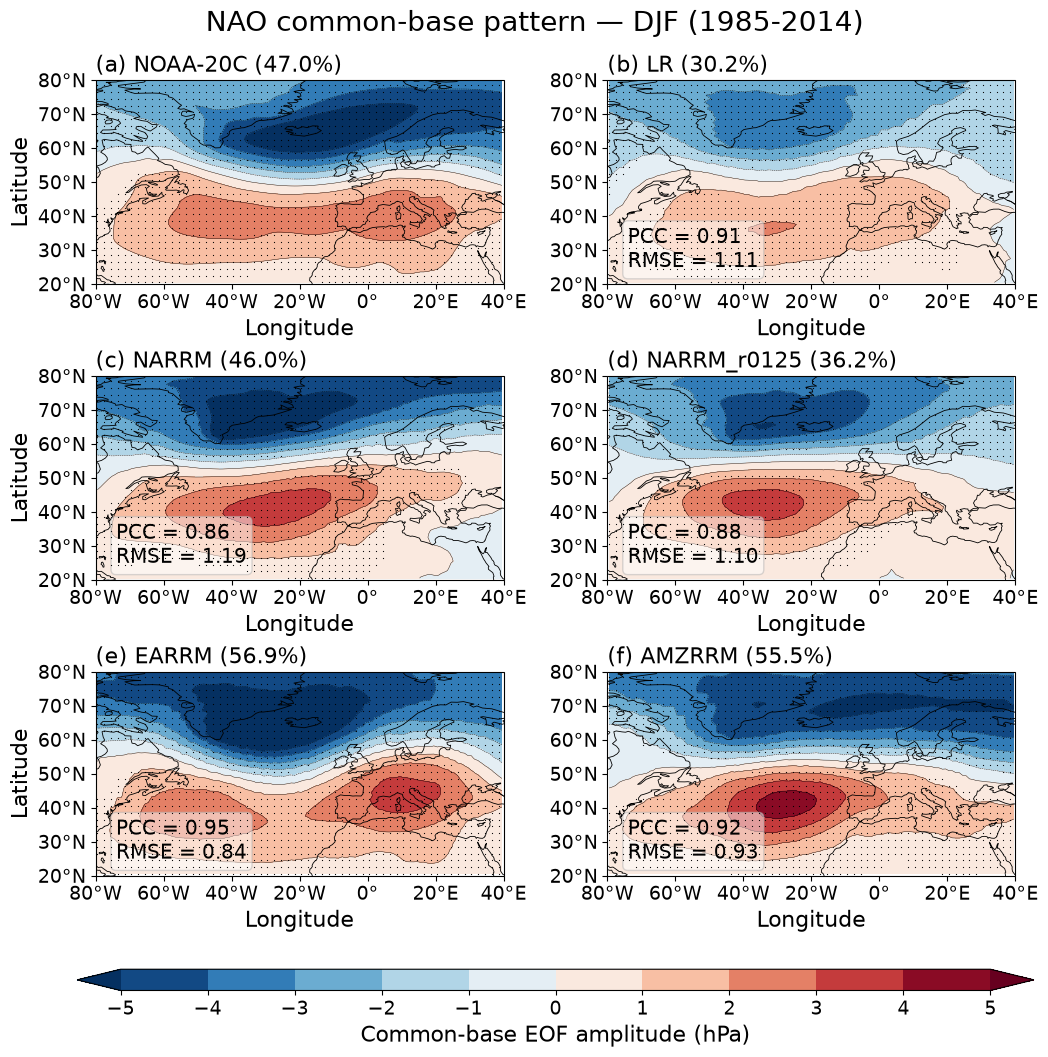

In [ ]:
# ── Figure 1 setup: edit values here ─────────────────────────────────────────
PATTERN_PLOT_CONFIG = dict(
    figure_name=f"{mode}_{season}_common_base_pattern_region_3x2.pdf",
    ncols=2,
    figsize_per_panel=(5.2, 3.6),
    dpi=300,
    fontz=16,
    cmap=CMAP,
    levels=np.array([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5], dtype=float),
    cbar_ticks=np.array([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5], dtype=float),
    cbar_tick_labels=None,
    cbar_label=f"Common-base EOF amplitude ({unit_label})" if unit_label else "Common-base EOF amplitude",
    central_longitude=0.0,
    xtick_step=20.0,
    ytick_step=10.0,
    wspace=0.15,
    hspace=0.45,
    cbar_pad=0.10,
    sig_level=0.05,
    dot_density=2,
    dot_size=3,
    show_significance=True,
)


def _label_with_frac(name, ds, frac_name):
    if frac_name in ds:
        return f"{name} ({float(ds[frac_name]) * 100:.1f}%)"
    return name


raw_cases_for_pattern = []
for i_case, (name, ds) in enumerate(all_cases):
    frac_name = "frac" if i_case == 0 else ("frac_proj" if "frac_proj" in ds else "frac")
    raw_cases_for_pattern.append((_label_with_frac(name, ds, frac_name), ds))

raw_pattern_plotter = ExtrapropicalModeMapPlotter(
    fig_dir=FIG_DIR,
    plot_dict={"reference": {"label": raw_cases_for_pattern[0][0]}, "hist": {"label": "E3SM"}},
    group_order=("hist",),
    obs_key="reference",
    lat_name="lat",
    lon_name="lon",
)

raw_pattern_fig, raw_pattern_axes = plot_raw_mode_pattern(
    map_plotter=raw_pattern_plotter,
    all_cases=raw_cases_for_pattern,
    mode=mode,
    token=season,
    filename=PATTERN_PLOT_CONFIG["figure_name"],
    region_lat_bounds=lat_bnds,
    region_lon_bounds=lon_bnds,
    obs_var=PATTERN_OBS_VAR,
    model_var=PATTERN_MODEL_VAR,
    obs_fallback="slope",
    model_fallback="slope_proj",
    pval_obs_var="slope_pval",
    pval_model_var="slope_pval_proj",
    pval_obs_fallback="slope_pval",
    pval_model_fallback="slope_pval",
    unit_scale=unit_scale,
    member_dim="member",
    title=f"{mode} common-base pattern — {season} ({period[0]}-{period[1]})",
    lon_convention="negpos",
    central_lon=PATTERN_PLOT_CONFIG["central_longitude"],
    ncols=PATTERN_PLOT_CONFIG["ncols"],
    figsize_per_panel=PATTERN_PLOT_CONFIG["figsize_per_panel"],
    fontz=PATTERN_PLOT_CONFIG["fontz"],
    fig_dpi=PATTERN_PLOT_CONFIG["dpi"],
    fig_format="pdf",
    xtick_step=PATTERN_PLOT_CONFIG["xtick_step"],
    yticks=np.arange(
        min(lat_bnds) if lat_bnds is not None else -90,
        (max(lat_bnds) if lat_bnds is not None else 90) + PATTERN_PLOT_CONFIG["ytick_step"] * 0.5,
        PATTERN_PLOT_CONFIG["ytick_step"],
    ),
    wspace=PATTERN_PLOT_CONFIG["wspace"],
    hspace=PATTERN_PLOT_CONFIG["hspace"],
    cb_pad=PATTERN_PLOT_CONFIG["cbar_pad"],
    cmap=PATTERN_PLOT_CONFIG["cmap"],
    mlevels=PATTERN_PLOT_CONFIG["levels"],
    cbar_ticks=PATTERN_PLOT_CONFIG["cbar_ticks"],
    cbar_tick_labels=PATTERN_PLOT_CONFIG["cbar_tick_labels"],
    cbar_label=PATTERN_PLOT_CONFIG["cbar_label"],
    area_weight=True,
    show_significance=PATTERN_PLOT_CONFIG["show_significance"],
    sig_level=PATTERN_PLOT_CONFIG["sig_level"],
    dot_density=PATTERN_PLOT_CONFIG["dot_density"],
    dot_size=PATTERN_PLOT_CONFIG["dot_size"],
)


### Figure 1b -- Model EOF Patterns with Significance Relative to Observations

In [ ]:
# Model EOF patterns, stippled where each model differs significantly from the observational reference

# =========================
# User-adjustable settings
# =========================

EOF_SIG_CFG = {
    # Cases
    "ref_case": "OBS",     # "OBS" uses obs_ds; use "LR" for an LR reference
    "compare_cases": None,  # None -> all model_list cases in model_results

    # Bootstrap test
    "sig_level": 0.05,      # Change to 0.10 for p < 0.10 stippling
    "n_boot": 300,
    "random_seed": 42,

    # Cache bootstrap p-values
    "use_cache": True,       # Load existing p-value files when compatible
    "save_cache": True,      # Save newly computed p-values for reuse
    "overwrite_cache": True,
    
    "cache_dir_name": "eof_diff_sig_cache",

    # Stippling
    "dot_density": 2,
    "dot_size": 8,

    # EOF plotting
    "pattern_levels": np.linspace(-5, 5, 11),
    "cmap": CMAP,

    # Figure layout
    "font_size": 18,
    "ncols": 2,
    "figsize_per_panel": (6, 4),
    "xtick_step": 20.0,
    "ytick_step": 10.0,

    # Output
    "fig_prefix": None,  # None -> automatic
    "fig_format": "pdf",
    "dpi": 300,
}


# =========================
# Derived settings
# =========================

REF_CASE = EOF_SIG_CFG["ref_case"]
REF_IS_OBS = str(REF_CASE).lower() in {"obs", "observation", "observations", "reference"}
REF_LABEL = obs_panel_label if REF_IS_OBS else str(REF_CASE)

COMPARE_CASES = (
    [case for case in model_list if case in model_results and (REF_IS_OBS or case != REF_CASE)]
    if EOF_SIG_CFG["compare_cases"] is None
    else EOF_SIG_CFG["compare_cases"]
)

EOF_DIFF_SIG_LEVEL = EOF_SIG_CFG["sig_level"]
EOF_DIFF_N_BOOT = EOF_SIG_CFG["n_boot"]
EOF_DIFF_RANDOM_SEED = EOF_SIG_CFG["random_seed"]

USE_EOF_DIFF_CACHE = EOF_SIG_CFG["use_cache"]
SAVE_EOF_DIFF_CACHE = EOF_SIG_CFG.get("save_cache", True)
OVERWRITE_EOF_DIFF_CACHE = EOF_SIG_CFG["overwrite_cache"]
EOF_DIFF_CACHE_DIR = os.path.join(FIG_DIR, EOF_SIG_CFG["cache_dir_name"])

EOF_DIFF_DOT_DENSITY = EOF_SIG_CFG["dot_density"]
EOF_DIFF_DOT_SIZE = EOF_SIG_CFG["dot_size"]

EOF_PATTERN_LEVELS = EOF_SIG_CFG["pattern_levels"]
CMAP_EOF = EOF_SIG_CFG["cmap"]

fontz = EOF_SIG_CFG["font_size"]
ncols_plot = EOF_SIG_CFG["ncols"]
figsize_per_panel = EOF_SIG_CFG["figsize_per_panel"]
xtick_step = EOF_SIG_CFG["xtick_step"]
ytick_step = EOF_SIG_CFG["ytick_step"]


# =========================
# Helper functions
# =========================

def wrap_lon_180(da, lon_name="lon"):
    """Convert longitude from [0, 360) to [-180, 180) and sort."""
    lon = da[lon_name]
    if float(lon.max()) > 180:
        da = da.assign_coords({lon_name: ((lon + 180) % 360) - 180})
    return da.sortby(lon_name)


def as_latlon(da):
    """Return lon-wrapped DataArray with lat/lon as trailing dims."""
    da = wrap_lon_180(da)

    if "lat" not in da.dims or "lon" not in da.dims:
        raise ValueError(f"Expected lat/lon dimensions, got {da.dims}")

    other_dims = [d for d in da.dims if d not in ("lat", "lon")]
    return da.transpose(*other_dims, "lat", "lon")


def subset_mode_domain(da):
    """Subset DataArray to configured lat/lon domain."""
    da = as_latlon(da)

    if lat_bnds is not None:
        da = da.sel(lat=slice(min(lat_bnds), max(lat_bnds)))

    if lon_bnds is not None:
        lon0, lon1 = lon_bnds

        if lon0 <= lon1:
            da = da.sel(lon=slice(lon0, lon1))
        else:
            da = xr.concat(
                [
                    da.sel(lon=slice(lon0, 180)),
                    da.sel(lon=slice(-180, lon1)),
                ],
                dim="lon",
            ).sortby("lon")

    return da


def calc_eof_svd(da, eof_num=1):
    """Calculate EOF pattern using latitude-weighted SVD."""
    da = as_latlon(da)

    if "time" not in da.dims:
        raise ValueError(f"EOF bootstrap requires a time dimension, got {da.dims}")

    da = da - da.mean("time")

    lat = da.lat.values
    weights = np.sqrt(np.cos(np.deg2rad(lat)))[:, None]

    weighted = da.values * weights[None, :, :]
    flat = weighted.reshape(weighted.shape[0], -1)

    valid = np.isfinite(flat).all(axis=0)

    if valid.sum() < eof_num:
        raise ValueError("Not enough valid grid cells for EOF bootstrap.")

    x = flat[:, valid]
    x = x - x.mean(axis=0, keepdims=True)

    _u, _s, vt = np.linalg.svd(x, full_matrices=False)

    eof_flat = np.full(flat.shape[1], np.nan, dtype=float)
    eof_flat[valid] = vt[eof_num - 1]

    eof_vals = eof_flat.reshape(da.sizes["lat"], da.sizes["lon"]) / weights

    return xr.DataArray(
        eof_vals,
        coords={"lat": da.lat, "lon": da.lon},
        dims=("lat", "lon"),
        name="eof",
    )


def align_and_rescale_eof(eof, target):
    """Align EOF sign/amplitude to target EOF using least-squares projection."""
    eof = as_latlon(eof)
    target = as_latlon(target)

    if not (
        np.array_equal(eof.lon.values, target.lon.values)
        and np.array_equal(eof.lat.values, target.lat.values)
    ):
        target = target.interp(lon=eof.lon, lat=eof.lat)

    x = eof.values
    y = target.values

    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() == 0:
        return eof

    denom = np.sum(x[mask] ** 2)

    if denom == 0 or not np.isfinite(denom):
        return eof

    scale = np.sum(x[mask] * y[mask]) / denom

    if not np.isfinite(scale):
        scale = 1.0

    return eof * scale


def bootstrap_diff_pvalue(
    case_anom,
    ref_anom,
    case_target,
    ref_target,
    n_boot=300,
    seed=42,
):
    """
    Bootstrap p-value for EOF pattern difference.

    At each grid cell, this tests whether the bootstrapped difference
    case_eof - ref_eof has a consistently positive or negative sign.
    """
    rng = np.random.default_rng(seed)

    case_anom = as_latlon(case_anom)
    ref_anom = as_latlon(ref_anom)
    case_target = as_latlon(case_target)
    ref_target = as_latlon(ref_target)

    valid = np.isfinite(case_target.values) & np.isfinite(ref_target.values)

    gt_count = np.zeros(case_target.shape, dtype=np.int32)
    lt_count = np.zeros(case_target.shape, dtype=np.int32)

    n_case = case_anom.sizes["time"]
    n_ref = ref_anom.sizes["time"]

    eof_num = int(mode_info.get("eof_num", 1))

    for iboot in range(n_boot):
        case_boot = case_anom.isel(
            time=rng.integers(0, n_case, size=n_case)
        )
        ref_boot = ref_anom.isel(
            time=rng.integers(0, n_ref, size=n_ref)
        )

        case_eof = calc_eof_svd(case_boot, eof_num=eof_num)
        ref_eof = calc_eof_svd(ref_boot, eof_num=eof_num)

        case_eof = align_and_rescale_eof(case_eof, case_target)
        ref_eof = align_and_rescale_eof(ref_eof, ref_target)

        diff = (case_eof - ref_eof).values

        gt_count += valid & (diff >= 0)
        lt_count += valid & (diff <= 0)

        if (iboot + 1) % 50 == 0 or (iboot + 1) == n_boot:
            print(f"  bootstrap {iboot + 1}/{n_boot}")

    pvals = 2.0 * np.minimum(
        (gt_count + 1) / (n_boot + 1),
        (lt_count + 1) / (n_boot + 1),
    )

    pvals = np.where(valid, np.clip(pvals, 0.0, 1.0), np.nan)

    return xr.DataArray(
        pvals,
        coords=case_target.coords,
        dims=case_target.dims,
        name="pvalue",
    )


def calc_pattern_corr_rmse(ref, test, w2d=None):
    """Calculate pattern correlation and RMSE against the reference panel."""
    mask = np.isfinite(ref) & np.isfinite(test)
    if w2d is not None:
        mask = mask & np.isfinite(w2d)
    if mask.sum() == 0:
        return np.nan, np.nan

    ref1 = ref[mask]
    test1 = test[mask]
    wt = None if w2d is None else w2d[mask]

    if wt is None:
        ref_mean = ref1.mean()
        test_mean = test1.mean()
        ref_anom = ref1 - ref_mean
        test_anom = test1 - test_mean
        denom = np.sqrt(np.sum(ref_anom**2) * np.sum(test_anom**2))
        pcorr = np.nan if denom == 0 else np.sum(ref_anom * test_anom) / denom
        rmse = np.sqrt(np.mean((test1 - ref1)**2))
    else:
        ref_mean = np.average(ref1, weights=wt)
        test_mean = np.average(test1, weights=wt)
        ref_anom = ref1 - ref_mean
        test_anom = test1 - test_mean
        denom = np.sqrt(np.sum(wt * ref_anom**2) * np.sum(wt * test_anom**2))
        pcorr = np.nan if denom == 0 else np.sum(wt * ref_anom * test_anom) / denom
        rmse = np.sqrt(np.average((test1 - ref1)**2, weights=wt))

    return pcorr, rmse


def make_cache_filename(case_name, seed):
    """Build cache filename independent of plotting significance threshold."""
    eof_num = int(mode_info.get("eof_num", 1))

    safe_mode = str(mode).replace(" ", "_")
    safe_season = str(season).replace(" ", "_")
    safe_field = str(field_var).replace(" ", "_")
    safe_case = str(case_name).replace(" ", "_")
    safe_ref = str(REF_LABEL).replace(" ", "_")

    fname = (
        f"{safe_mode}_{safe_season}_{safe_field}_"
        f"{safe_case}_vs_{safe_ref}_"
        f"eof{eof_num}_"
        f"nboot{EOF_DIFF_N_BOOT}_"
        f"seed{seed}_pval.nc"
    )

    return os.path.join(EOF_DIFF_CACHE_DIR, fname)


def pvalue_cache_is_compatible(pval, case_name, seed, target):
    """Check whether a cached p-value file matches this plot request."""
    expected_attrs = {
        "case": str(case_name),
        "reference_case": str(REF_LABEL),
        "mode": str(mode),
        "season": str(season),
        "field_var": str(field_var),
        "eof_num": int(mode_info.get("eof_num", 1)),
        "n_boot": int(EOF_DIFF_N_BOOT),
        "seed": int(seed),
    }

    for key, expected in expected_attrs.items():
        if pval.attrs.get(key) != expected:
            return False

    return (
        pval.dims == target.dims
        and np.array_equal(pval.lon.values, target.lon.values)
        and np.array_equal(pval.lat.values, target.lat.values)
    )


def get_or_compute_eof_diff_pvalue(
    case_name,
    case_anom,
    ref_anom,
    case_target,
    ref_target,
    seed,
):
    """Load cached EOF-difference p-values or compute and save them."""
    os.makedirs(EOF_DIFF_CACHE_DIR, exist_ok=True)

    cache_file = make_cache_filename(case_name, seed)

    if USE_EOF_DIFF_CACHE and os.path.exists(cache_file) and not OVERWRITE_EOF_DIFF_CACHE:
        try:
            cached = xr.open_dataarray(cache_file)
            pval_cached = cached.load()
            cached.close()

            if pvalue_cache_is_compatible(pval_cached, case_name, seed, case_target):
                print(f"Loading cached EOF-difference p-values -> {cache_file}")
                return pval_cached

            print(f"Ignoring incompatible cached EOF-difference p-values -> {cache_file}")
        except Exception as exc:
            print(f"Could not read cached EOF-difference p-values ({exc}); recomputing -> {cache_file}")

    print(f"Computing EOF-difference p-values -> {cache_file}")

    pval = bootstrap_diff_pvalue(
        case_anom=case_anom,
        ref_anom=ref_anom,
        case_target=case_target,
        ref_target=ref_target,
        n_boot=EOF_DIFF_N_BOOT,
        seed=seed,
    )

    pval.attrs.update(
        {
            "description": f"Bootstrap p-value for EOF pattern difference: {case_name} - {REF_LABEL}",
            "case": str(case_name),
            "reference_case": str(REF_LABEL),
            "mode": str(mode),
            "season": str(season),
            "field_var": str(field_var),
            "eof_num": int(mode_info.get("eof_num", 1)),
            "n_boot": int(EOF_DIFF_N_BOOT),
            "seed": int(seed),
            "note": (
                "Two-sided bootstrap sign test of EOF pattern difference at each grid cell. "
                "The saved p-values can be reused with different plotting thresholds, e.g., p<0.05 or p<0.10."
            ),
        }
    )

    if SAVE_EOF_DIFF_CACHE:
        pval.to_netcdf(cache_file)
        print(f"Saved cached EOF-difference p-values -> {cache_file}")

    return pval


# =========================
# Data preparation
# =========================

if not REF_IS_OBS and REF_CASE not in model_results:
    raise KeyError(
        f"REF_CASE={REF_CASE!r} is not OBS and is not in model_results. "
        f"Available: {list(model_results)}"
    )

if not COMPARE_CASES:
    raise ValueError("No RRM cases found to compare against reference case.")

anom_key = f"{field_var}_anom"

ref_ds = obs_ds if REF_IS_OBS else model_results[REF_CASE]

if anom_key not in ref_ds:
    raise KeyError(
        f"{anom_key!r} is required for EOF bootstrap but was not saved for {REF_LABEL}."
    )

ref_target = subset_mode_domain(ref_ds["eof"] * unit_scale)
ref_anom = subset_mode_domain(ref_ds[anom_key] * unit_scale)
ref_frac = float(ref_ds["frac"]) * 100 if "frac" in ref_ds else None

lat_plot = ref_target.lat.values
lon_plot = ref_target.lon.values
w = np.cos(np.deg2rad(lat_plot)).astype(float)
w = w / np.nanmean(w)
w2d = w[:, None] * np.ones((lat_plot.size, lon_plot.size), dtype=float)

plot_records = [(REF_LABEL, ref_target, None, ref_frac)]


for case_name in COMPARE_CASES:
    case_ds = model_results[case_name]

    if anom_key not in case_ds:
        raise KeyError(
            f"{anom_key!r} is required for EOF bootstrap but was not saved for {case_name}."
        )

    case_target = subset_mode_domain(case_ds["eof"] * unit_scale)
    case_anom = subset_mode_domain(case_ds[anom_key] * unit_scale)

    if not (
        np.array_equal(case_target.lon.values, ref_target.lon.values)
        and np.array_equal(case_target.lat.values, ref_target.lat.values)
    ):
        case_target = case_target.interp(lon=ref_target.lon, lat=ref_target.lat)
        case_anom = case_anom.interp(lon=ref_target.lon, lat=ref_target.lat)

    seed = EOF_DIFF_RANDOM_SEED + len(plot_records)

    pval = get_or_compute_eof_diff_pvalue(
        case_name=case_name,
        case_anom=case_anom,
        ref_anom=ref_anom,
        case_target=case_target,
        ref_target=ref_target,
        seed=seed,
    )

    frac = float(case_ds["frac"]) * 100 if "frac" in case_ds else None

    plot_records.append((case_name, case_target, pval, frac))

    sig_pct = float(np.nanmean(pval.values < EOF_DIFF_SIG_LEVEL) * 100.0)

    print(
        f"{case_name} - {REF_LABEL}: "
        f"significant grid cells p<{EOF_DIFF_SIG_LEVEL:.2f}: {sig_pct:.1f}%"
    )


# =========================
# Color levels
# =========================

if EOF_PATTERN_LEVELS is None:
    all_eof = np.concatenate([rec[1].values.ravel() for rec in plot_records])
    finite = np.isfinite(all_eof)

    pattern_vmax = (
        float(np.nanpercentile(np.abs(all_eof[finite]), 98))
        if np.any(finite)
        else 1.0
    )

    if pattern_vmax == 0 or not np.isfinite(pattern_vmax):
        pattern_vmax = 1.0

    EOF_PATTERN_LEVELS = np.linspace(-pattern_vmax, pattern_vmax, 11)


# =========================
# Plot
# =========================

nrows = int(np.ceil(len(plot_records) / ncols_plot))

fig_w = figsize_per_panel[0] * ncols_plot
fig_h = figsize_per_panel[1] * nrows + 0.9

proj = ccrs.PlateCarree(central_longitude=0.0)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(fig_w, fig_h))

axes = [
    fig.add_subplot(nrows, ncols_plot, i + 1, projection=proj)
    for i in range(nrows * ncols_plot)
]

fig.subplots_adjust(
    left=0.06,
    right=0.98,
    top=0.90,
    bottom=0.14,
    wspace=0.05,
    hspace=0.40,
)

#fig.suptitle(
#    (
#        f"{mode} EOF patterns -- stippling indicates difference from "
#        f"{REF_LABEL} at bootstrap p<{EOF_DIFF_SIG_LEVEL:.2f}"
#    ),
#    fontsize=fontz * 1.2,
#    y=0.98,
#)

extent = [
    float(ref_target.lon.min()),
    float(ref_target.lon.max()),
    float(ref_target.lat.min()),
    float(ref_target.lat.max()),
]

xticks = np.arange(
    np.ceil(extent[0] / xtick_step) * xtick_step,
    np.floor(extent[1] / xtick_step) * xtick_step + xtick_step * 0.5,
    xtick_step,
)

yticks = np.arange(
    np.ceil(extent[2] / ytick_step) * ytick_step,
    np.floor(extent[3] / ytick_step) * ytick_step + ytick_step * 0.5,
    ytick_step,
)

panel_labels = list(string.ascii_lowercase)

im = None

for i, ax in enumerate(axes):
    if i >= len(plot_records):
        ax.set_visible(False)
        continue

    case_name, eof_field, pval, frac = plot_records[i]

    im = ax.contourf(
        eof_field.lon.values,
        eof_field.lat.values,
        eof_field.values,
        levels=EOF_PATTERN_LEVELS,
        cmap=CMAP_EOF,
        extend="both",
        transform=data_crs,
    )

    ax.contour(
        eof_field.lon.values,
        eof_field.lat.values,
        eof_field.values,
        levels=EOF_PATTERN_LEVELS,
        colors="k",
        linewidths=0.3,
        alpha=0.65,
        transform=data_crs,
    )

    if pval is not None:
        add_sig_dots_plain(
            ax,
            pval,
            sig_level=EOF_DIFF_SIG_LEVEL,
            dot_density=EOF_DIFF_DOT_DENSITY,
            dot_size=EOF_DIFF_DOT_SIZE,
            transform=data_crs,
        )

    ax.coastlines(linewidth=0.6)
    ax.set_extent(extent, crs=data_crs)

    ax.set_xticks(xticks, crs=data_crs)
    ax.set_yticks(yticks, crs=data_crs)

    ax.xaxis.set_major_formatter(LongitudeFormatter(number_format=".0f"))
    ax.yaxis.set_major_formatter(LatitudeFormatter(number_format=".0f"))

    ax.tick_params(labelsize=fontz * 0.85)

    ax.gridlines(
        linewidth=0.4,
        color="gray",
        alpha=0.5,
        linestyle="--",
        draw_labels=False,
    )

    if i % ncols_plot == 0:
        ax.set_ylabel("Latitude")

    ax.set_xlabel("Longitude")

    frac_str = f" ({frac:.1f}%)" if frac is not None else ""
    ref_str = "" #" reference" if case_name == REF_LABEL else ""

    ax.set_title(
        f"({panel_labels[i]}) {case_name}{frac_str}{ref_str}",
        fontsize=fontz,
        loc="left",
        pad=6,
    )

    if i != 0:
        pcorr, rmse = calc_pattern_corr_rmse(ref_target.values, eof_field.values, w2d=w2d)
        print(f"{case_name} vs {REF_LABEL}: PCC={pcorr:.3f}, RMSE={rmse:.3f}")
        ax.text(
            0.05,
            0.05,
            f"PCC = {pcorr:.2f}\nRMSE = {rmse:.2f}",
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=fontz * 0.85,
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="0.6",
                alpha=0.5,
            ),
            zorder=5,
        )


cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.10,
    aspect=45,
    ticks=EOF_PATTERN_LEVELS,
)

cbar.set_label(
    f"EOF amplitude ({unit_label})" if unit_label else "EOF amplitude",
    fontsize=fontz,
)

cbar.ax.tick_params(labelsize=fontz * 0.85)


# =========================
# Save figure
# =========================

fig_prefix = EOF_SIG_CFG["fig_prefix"]

if fig_prefix is None:
    fig_prefix = (
        f"{mode}_{season}_eof_pattern_model_sig_vs_"
        f"{REF_LABEL}_bootstrap_p{EOF_DIFF_SIG_LEVEL}"
    )

fig_path = os.path.join(
    FIG_DIR,
    f"{fig_prefix}.{EOF_SIG_CFG['fig_format']}",
)

fig.savefig(
    fig_path,
    dpi=EOF_SIG_CFG["dpi"],
    bbox_inches="tight",
    pad_inches=0.05,
)

print(f"Saved -> {fig_path}")

plt.show()

Computing EOF-difference p-values -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/eof_diff_sig_cache/NAO_DJF_psl_LR_vs_NOAA-20C_eof1_nboot300_seed43_pval.nc
  bootstrap 50/300
  bootstrap 100/300
  bootstrap 150/300
  bootstrap 200/300
  bootstrap 250/300
  bootstrap 300/300
Saved cached EOF-difference p-values -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/eof_diff_sig_cache/NAO_DJF_psl_LR_vs_NOAA-20C_eof1_nboot300_seed43_pval.nc
LR - NOAA-20C: significant grid cells p<0.05: 15.4%
Computing EOF-difference p-values -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/eof_diff_sig_cache/NAO_DJF_psl_NARRM_vs_NOAA-20C_eof1_nboot300_seed44_pval.nc
  bootstrap 50/300
  bootstrap 100/300
  bootstrap 150/300
  bootstrap 200/300
  bootstrap 250/300
  bootstrap 300/300
Saved cached EOF-difference p-values -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/eof_diff_sig_cache/NAO_DJF_psl_NARRM_vs_NOAA-20C_eof

KeyboardInterrupt: 

### Figure 2 — Global Regression Map with Significance Stippling

In [ ]:
# ── Figure 2 setup: edit values here ─────────────────────────────────────────
TELECONNECTION_PLOT_CONFIG = dict(
    figure_name=f"{mode}_{season}_{PLOT_VAR}_global_sig{SIG_LEVEL}.pdf",
    ncols=2,
    figsize_per_panel=(6.0, 4.0),
    dpi=300,
    fontz=18,
    cmap=CMAP,
    levels=np.linspace(-reg_vmax, reg_vmax, 11) if np.isfinite(reg_vmax) and reg_vmax > 0 else np.linspace(-3.0, 3.0, 11),
    cbar_ticks=None,  # None -> use all contour levels
    cbar_tick_labels=None,
    cbar_label=f"Regression coefficient ({unit_label} std$^{{-1}}$)" if unit_label else "Regression coefficient",
    central_longitude=180.0,
    xtick_step=60.0,
    yticks=np.arange(-90, 91, 30),
    wspace=0.15,
    hspace=0.42,
    cbar_pad=0.08,
    sig_level=SIG_LEVEL,
    dot_density=4,
    dot_size=8,
    show_significance=True,
)

raw_teleconnection_plotter = ExtrapropicalModeMapPlotter(
    fig_dir=FIG_DIR,
    plot_dict={"reference": {"label": obs_panel_label}, "hist": {"label": "E3SM"}},
    group_order=("hist",),
    obs_key="reference",
    lat_name="lat",
    lon_name="lon",
)

raw_teleconnection_fig, raw_teleconnection_axes = plot_raw_teleconnection(
    map_plotter=raw_teleconnection_plotter,
    all_cases=all_cases,
    mode=mode,
    token=season,
    filename=TELECONNECTION_PLOT_CONFIG["figure_name"],
    obs_var=PLOT_VAR,
    model_var=PLOT_VAR,
    obs_fallback="slope",
    model_fallback="slope",
    pval_obs_var=PVAL_VAR,
    pval_model_var=PVAL_VAR,
    pval_obs_fallback="slope_pval",
    pval_model_fallback="slope_pval",
    unit_scale=unit_scale,
    member_dim="member",
    title=f"{mode} teleconnection — {season} ({period[0]}-{period[1]})",
    central_lon=TELECONNECTION_PLOT_CONFIG["central_longitude"],
    ncols=TELECONNECTION_PLOT_CONFIG["ncols"],
    figsize_per_panel=TELECONNECTION_PLOT_CONFIG["figsize_per_panel"],
    fontz=TELECONNECTION_PLOT_CONFIG["fontz"],
    fig_dpi=TELECONNECTION_PLOT_CONFIG["dpi"],
    fig_format="pdf",
    xtick_step=TELECONNECTION_PLOT_CONFIG["xtick_step"],
    yticks=TELECONNECTION_PLOT_CONFIG["yticks"],
    wspace=TELECONNECTION_PLOT_CONFIG["wspace"],
    hspace=TELECONNECTION_PLOT_CONFIG["hspace"],
    cb_pad=TELECONNECTION_PLOT_CONFIG["cbar_pad"],
    cmap=TELECONNECTION_PLOT_CONFIG["cmap"],
    mlevels=TELECONNECTION_PLOT_CONFIG["levels"],
    cbar_ticks=(
        TELECONNECTION_PLOT_CONFIG["levels"]
        if TELECONNECTION_PLOT_CONFIG["cbar_ticks"] is None
        else TELECONNECTION_PLOT_CONFIG["cbar_ticks"]
    ),
    cbar_tick_labels=TELECONNECTION_PLOT_CONFIG["cbar_tick_labels"],
    cbar_label=TELECONNECTION_PLOT_CONFIG["cbar_label"],
    area_weight=True,
    show_significance=TELECONNECTION_PLOT_CONFIG["show_significance"],
    sig_level=TELECONNECTION_PLOT_CONFIG["sig_level"],
    dot_density=TELECONNECTION_PLOT_CONFIG["dot_density"],
    dot_size=TELECONNECTION_PLOT_CONFIG["dot_size"],
)


## Plot: PC Time Series Comparison

Plots the standardized PC time series for obs and all models on one panel.

- `PC_VAR = "pc"` → independent EOF basis (each dataset's own EOF)
- `PC_VAR = "pc_proj"` → common-base (projected onto obs EOF) — better for direct comparison

In [ ]:
# PC time-series plotting now uses MultimodelPCTimeSeriesPlotter through
# pcmdi_mov_workflow.plot_raw_pc_timeseries, matching the PCMDI-result workflow.


In [ ]:
PC_VAR = "pc_proj"

pc_label = {
    "pc": "Principal Component",
    "pc_proj": "Projected Principal Component",
}[PC_VAR]

pc_desc = {
    "pc": "independent EOF basis",
    "pc_proj": "projected onto OBS EOF",
}[PC_VAR]

MODEL_STYLES = {
    "LR": {
        "color": "tab:blue",
        "linestyle": "-",
        "marker": "o",
    },
    "NARRM": {
        "color": "tab:orange",
        "linestyle": "-",
        "marker": "s",
    },
    "NARRM_r0125": {
        "color": "tab:orange",
        "linestyle": "--",
        "marker": "s",
    },
    "EARRM": {
        "color": "tab:green",
        "linestyle": "-",
        "marker": "^",
    },
    "AMZRRM": {
        "color": "tab:purple",
        "linestyle": "-",
        "marker": "D",
    },
}

PLOT_CONFIG = dict(
    # Output
    figure_name=(
        f"{mode}_{season}_{period[0]}_{period[1]}_"
        f"{PC_VAR}_standardized_pc_timeseries.pdf"
    ),

    # Figure
    fontz=18,
    figsize=(14, 6),
    dpi=400,

    # OBS bars
    obs_bar_width=0.80,
    obs_bar_alpha=0.18,
    obs_bar_color="black",
    obs_bar_edgecolor="black",
    obs_bar_linewidth=0.8,
    obs_label=mode_dict[mode]["obs"],

    # Model marker-lines
    linewidth_model=2.3,
    markersize=6.0,
    markeredgewidth=1.0,
    alpha_model=0.95,
    model_styles=MODEL_STYLES,

    # Legend
    legend_below=True,
    legend_frameon=True,
    legend_edgecolor="black",
    legend_facecolor="white",
    legend_framealpha=1.0,
    legend_ncol=3,
    time_coord_offset=-1 if season == "DJF" else 0,
    xlim=(period[0] - 0.5, period[1] + 0.5),
    xtick_step=2,
    xtick_start=period[0] + (period[0] % 2),
    xtick_end=period[1],
    legend_stat="std_ratio",  # "std_ratio", "var_ratio", "corr", or "none"

    # Other options
    show_corr=True,
    show_corr_significance=True,
    show_corr_pvalue=False,
    ylim=None,

    title=(
        f"{mode} ({season}, {period[0]}-{period[1]}) | "
        f"Standardized {pc_label} ({pc_desc})"
    ),
)

raw_pc_fig, raw_pc_ax = plot_raw_pc_timeseries(
    pc_plotter=MultimodelPCTimeSeriesPlotter(
        fig_dir=FIG_DIR,
        plot_dict={"reference": {"label": PLOT_CONFIG["obs_label"]}, "hist": {"label": "E3SM"}},
        group_order=("hist",),
        obs_key="reference",
    ),
    all_cases=all_cases,
    mode=mode,
    token=season,
    filename=PLOT_CONFIG.pop("figure_name"),
    pc_var=PC_VAR,
    pc_fallback="pc",
    member_dim="member",
    **PLOT_CONFIG,
)


## Batch Pattern Maps

Source: `tmp_plot_sources/plot_mov_batch.ipynb`


# Extratropical Modes of Variability — Batch Pattern Maps

Iterates over **all modes × all seasons** to produce EOF pattern and teleconnection slope figures,
using `pcmdi_mov_reader.EMOVDiagReader` and `movs_plotter.ExtrapropicalModeMapPlotter`.

**Notebook structure:**
1. Imports (including `ExtrapropicalModeMapPlotter`)
2. Shared configuration (paths, modes, models, reader + plotter)
3. Batch loop — all modes × all seasons

> For interactive single-mode exploration, see [`plot_mov_pattern.ipynb`](tmp_plot_sources/plot_mov_pattern.ipynb).

## Imports

In [ ]:
import os
import sys
from pathlib import Path
from typing import Dict, Sequence, Optional, Tuple, Any, List

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import math

conda_prefix = Path(os.environ.get("CONDA_PREFIX", "/home/ac.szhang/.conda/envs/zppy-pcmdi-diags"))
proj_data_dir = conda_prefix / "share" / "proj"
if (proj_data_dir / "proj.db").exists():
    os.environ["PROJ_LIB"] = str(proj_data_dir)
    os.environ["PROJ_DATA"] = str(proj_data_dir)
    try:
        import pyproj
        pyproj.datadir.set_data_dir(str(proj_data_dir))
    except Exception as exc:
        print(f"Warning: could not set pyproj data dir: {exc}")

import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

for package_root in (Path("."), Path("..")):
    for module_dir in (package_root / "scripts", package_root / "util"):
        if module_dir.exists():
            sys.path.insert(0, str(module_dir.resolve()))
    if (package_root / "scripts").exists() or (package_root / "util").exists():
        break

from pcmdi_mov_reader import ModeFileSpec, EMOVDiagReader
from movs_plotter import ExtrapropicalModeMapPlotter

## Shared Configuration

Run this cell once before the batch loop. Defines paths, the mode registry, model list, and instantiates the reader and plotter.

In [ ]:
TOP_DIR  = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_rrm_paper"
DATA_DIR = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi"
FIG_DIR  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper"
os.makedirs(FIG_DIR, exist_ok=True)

# Mode configuration: EOF component, driving variable, obs dataset, and optional
# regional bounds (lat_bnds/lon_bnds) used for pattern plots and stats.
mode_dict = {
    # SST-based ocean modes
    "AMO":  {"eof": "eof1", "var": "ts",  "obs": "HadISST2",  "lat_bnds": (0, 70),    "lon_bnds": (-80, 0)},
    "PDO":  {"eof": "eof1", "var": "ts",  "obs": "HadISST2"},
    "NPGO": {"eof": "eof2", "var": "ts",  "obs": "HadISST2"},
    # Northern Hemisphere SLP modes
    "NAM":  {"eof": "eof1", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (20, 90),   "lon_bnds": (-180, 180)},
    "NAO":  {"eof": "eof1", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (20, 80),   "lon_bnds": (-80, 40)},
    "NPO":  {"eof": "eof2", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (20, 80),   "lon_bnds": (120, -120)},  # lon wrap
    "PNA":  {"eof": "eof1", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (20, 80),   "lon_bnds": (120, -60)},
    # Southern Hemisphere SLP modes
    "SAM":  {"eof": "eof1", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (-90, -20), "lon_bnds": (-180, 180)},
    "PSA1": {"eof": "eof2", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (-90, -20), "lon_bnds": (120, -60)},
    "PSA2": {"eof": "eof3", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (-90, -20), "lon_bnds": (120, -60)},
}

MODEL = [
    "v3.NARRM.amip_0101",
    "v3.NARRM_r0125.amip_0101",
    "v3.EARRM.amip_0101",
    "v3.AMZRRM.amip_0101",
]
PERIOD = (1985, 2014)

obs_dataset_map = {m: cfg["obs"] for m, cfg in mode_dict.items()}

if "EMOVDiagReader" not in globals() or "ExtrapropicalModeMapPlotter" not in globals():
    import sys
    from pathlib import Path
    for package_root in (Path("."), Path("..")):
        for module_dir in (package_root / "scripts", package_root / "util"):
            if module_dir.exists():
                sys.path.insert(0, str(module_dir.resolve()))
        if (package_root / "scripts").exists() or (package_root / "util").exists():
            break
    from pcmdi_mov_reader import ModeFileSpec, EMOVDiagReader
    from movs_plotter import ExtrapropicalModeMapPlotter

reader = EMOVDiagReader(
    data_dir=DATA_DIR,
    prefer_cbf=True,
    obs_key="obs",
    model_key="e3sm",
    target_lat_name="latitude",
    target_lon_name="longitude_a",
    obs_dataset_map=obs_dataset_map,
    normalize_lon_360=True,
    sort_latlon=True,
)

plotter = ExtrapropicalModeMapPlotter(
    fig_dir=FIG_DIR,
    plot_dict={"reference": {"label": "Obs"}, "hist": {"label": "E3SM"}},
    group_order=("hist",),
    obs_key="reference",
    lat_name="latitude",
    lon_name="longitude_a",
)

## Batch Loop: All Modes × All Seasons

Iterates over every mode and its applicable season/frequency tokens.
Uncomment the `plotter.plot_mode_season_maps(...)` call to write figures to disk.

In [ ]:
# ── Batch settings ────────────────────────────────────────────────────────────
SEASONS_PSL = ["DJF", "MAM", "JJA", "SON", "monthly", "yearly"]
FREQ_TS     = "monthly"   # token for ts-based modes; change to "yearly" if needed
# ──────────────────────────────────────────────────────────────────────────────

for mode, cfg in mode_dict.items():
    var    = cfg["var"]
    eof    = cfg["eof"]
    tokens = SEASONS_PSL if var == "psl" else [FREQ_TS]

    for token in tokens:
        spec = ModeFileSpec(mode=mode, var=var, eof=eof, period=PERIOD, season_or_freq=token)

        dd_pattern = reader.build_multimodel_stack(MODEL, spec, which="eof",   member_dim="member")
        dd_slope   = reader.build_multimodel_stack(MODEL, spec, which="slope", member_dim="member")

        products = {
            "pattern":  dd_pattern,
            "teleconn": dd_slope,
        }
        product_labels = {
            "pattern":  f"{mode} {token} ({var}, {eof.upper()}) EOF pattern",
            "teleconn": f"{mode} {token} ({var}, {eof.upper()}) teleconn slope",
        }
        cb_labels = {"pattern": "EOF amplitude", "teleconn": "Regression coefficient"}
        fname     = f"{mode}_{token}_{var}_{eof}_pattern_teleconn.pdf"

        # Uncomment to produce figures:
        # plotter.plot_mode_season_maps(
        #     mode=mode,
        #     season=token,
        #     products=products,
        #     product_order=["pattern", "teleconn"],
        #     product_labels=product_labels,
        #     cb_labels_by_product=cb_labels,
        #     filename=fname,
        #     overlay_spread=True,
        #     spread_quantile=0.75,
        #     cmap="RdBu_r",
        #     one_colorbar_per_row=True,
        # )
        print("Prepared:", fname)